## Info!

The analysis here is done on a simulated CCD image using the G4 and WADERs toolkits on the Lyon cluster. I simulated 2000 events on a 6000,1500 ccd, and then took the 1480,480 corner of the ccd to reduce the amount of image we are working with for better visualization. 

## Imports

In [1]:
import pysimdamicm

import ROOT

import pandas as pd
import numpy as np
from astropy.io import fits
import matplotlib
import matplotlib.pyplot as plt

In [2]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from skimage.measure import label, regionprops

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

In [3]:
plt.rcParams["text.usetex"] = False
plt.rcParams["mathtext.default"] = "regular"

### Helpers

Thresholding options

In [4]:
# helper to make threshold cut to image to remove noise
def apply_percentile_threshold(cal_img, percentile=95, fill_value=np.nan):
    """
    Apply a global percentile cut on the RAW calibrated image (E in e-).
    Pixels <= threshold are set to `fill_value` (np.nan by default).

    Returns:
      masked_img : 2D array with only >thr pixels kept
      thr        : numeric threshold used
      keep       : boolean mask (True for kept pixels)
    """
    thr = np.percentile(cal_img, percentile)  # compute on RAW E
    keep = cal_img > thr                      # strict '>' to drop exactly bottom p%
    masked_img = np.where(keep, cal_img, fill_value)
    return masked_img, thr, keep

In [5]:
def apply_energy_threshold(cal_img, thr_keV, fill_value=np.nan):
    """
    Apply a fixed energy threshold to a CCD image calibrated in keV.
    Pixels with energy <= thr_keV are masked out.

    Parameters
    ----------
    cal_img : 2D array (in keV)
        Calibrated CCD image.
    thr_keV : float
        Threshold in keV. Pixels <= thr_keV are suppressed.
    fill_value : number, optional
        Replacement value for masked-out pixels (default: NaN).

    Returns
    -------
    masked_img : 2D array
        Image keeping only pixels above threshold.
    thr_keV : float
        Echo of threshold used.
    keep : 2D boolean array
        True where pixel > thr_keV.
    """
    keep = cal_img > thr_keV
    masked_img = np.where(keep, cal_img, fill_value)
    return masked_img, thr_keV, keep

Make samples logged or not logged in E

In [6]:
# log scale data, may not be necessary but I think I used it for the original so will do it again
def make_samples_logE(masked_img):
    """
    Build N x 3 samples from a thresholded CCD image (in keV).
    Uses log(E) as the third feature.
    Assumes masked_img has NaNs or zeros removed already via thresholding.
    
    Returns:
      X_raw : (N,3) with columns [y, x, log(E)]
      idx_yx: (N,2) integer pixel coords [y, x]
    """
    valid = np.isfinite(masked_img) & (masked_img > 0)
    ys, xs = np.nonzero(valid)
    E = masked_img[ys, xs].astype(np.float64)

    # Use pure natural log
    logE = np.log(E)

    X_raw = np.column_stack([ys, xs, logE])
    idx_yx = np.column_stack([ys, xs])
    return X_raw, idx_yx

In [7]:
def make_samples(masked_img):
    """
    Build N x 3 samples from a thresholded CCD image (in keV).
    Uses raw E (no log) as the third feature.

    Returns:
      X_raw : (N,3) with columns [y, x, E]
      idx_yx: (N,2) integer pixel coords [y, x]
    """
    valid = np.isfinite(masked_img) & (masked_img > 0)
    ys, xs = np.nonzero(valid)
    E = masked_img[ys, xs].astype(np.float64)

    X_raw = np.column_stack([ys, xs, E])
    idx_yx = np.column_stack([ys, xs])
    return X_raw, idx_yx

Fit GMM

In [8]:
REG_COVAR = 1e-6
RANDOM_STATE = 209

def _unscale_covariances(gmm, scaler):
    """
    Map covariances from standardized space back to original feature space.
    Handles only covariance_type='full' (what you're using).
    """
    if gmm.covariance_type != "full":
        raise ValueError("This helper currently assumes covariance_type='full'.")

    D = np.diag(scaler.scale_)
    covs_std = gmm.covariances_                 # shape: (K, d, d)
    covs_raw = np.empty_like(covs_std)
    for k in range(covs_std.shape[0]):
        covs_raw[k] = D @ covs_std[k] @ D       # Σ_raw = D Σ_std D
    return covs_raw

def fit_gmms_over_K(X_raw, K_RANGE, reg_covar=REG_COVAR, random_state=RANDOM_STATE):
    """
    Standardize features, fit a full-covariance GMM for each K.
    Returns: list of dicts with model, labels, BIC, AIC, scaler, and
             means/covariances mapped back to ORIGINAL units.
    """
    scaler = StandardScaler()
    X_std = scaler.fit_transform(X_raw)

    results = []
    for K in K_RANGE:
        gmm = GaussianMixture(
            n_components=K,
            covariance_type="full",
            reg_covar=reg_covar,
            random_state=random_state
        )
        gmm.fit(X_std)

        # Predict labels in standardized space, but keep for reference
        labels = gmm.predict(X_std)

        # --- NEW: parameters in original (unscaled) space ---
        means_raw = scaler.inverse_transform(gmm.means_)       # shape: (K, d)
        covs_raw  = _unscale_covariances(gmm, scaler)          # shape: (K, d, d)

        bic = gmm.bic(X_std)
        aic = gmm.aic(X_std)
        results.append({
            "K": K,
            "model": gmm,
            "labels": labels,         # labels on the standardized X
            "bic": bic,
            "aic": aic,
            "scaler": scaler,
            "means_raw": means_raw,   # <-- in original units
            "covs_raw": covs_raw      # <-- in original units
        })

    results.sort(key=lambda r: r["bic"])
    return results

Plotting options

In [9]:
from matplotlib.colors import ListedColormap

def plot_fullframe_clusters(idx_yx, labels, frame_size=(320, 640), title=None):
    H, W = frame_size
    y = idx_yx[:, 0]
    x = idx_yx[:, 1]

    # ---- Build image storing cluster labels ----
    img = np.full((H, W), -1, dtype=int)
    img[y, x] = labels

    # ---- Define colors ----
    light_blue = [0.45, 0.75, 0.95, 1.0]   # clear light blue
    dark_pink  = [0.80, 0.10, 0.45, 1.0]   # strong pink/magenta

    colors = np.vstack([
        [1, 1, 1, 1],     # background = white
        light_blue,       # cluster 0
        dark_pink         # cluster 1
    ])

    cmap = ListedColormap(colors)

    img_plot = img + 1  # shift background (-1) → 0

    # ---- Plot ----
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(img_plot, origin='lower', cmap=cmap, interpolation='none')

    ax.set_xlim(0, W)
    ax.set_ylim(0, H)
    ax.set_aspect('equal', 'box')
    ax.set_xlabel("Column index (x)")
    ax.set_ylabel("Row index (y)")
    ax.set_title(title if title else "GMM clusters (full frame)")

    plt.tight_layout()
    plt.show()




In [10]:
def plot_cluster_gallery(idx_yx, result, max_points_per_cluster=None):
    """
    Plot the cluster gallery for a single (best) result.
    """
    y_all, x_all = idx_yx[:, 0], idx_yx[:, 1]

    K = result["K"]
    labels = result["labels"]

    ncols = int(np.ceil(np.sqrt(K)))
    nrows = int(np.ceil(K / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.2 * ncols, 3.2 * nrows),
        squeeze=False
    )
    fig.suptitle(f"GMM clusters (K={K}) — no overlay", y=0.98)

    rng = np.random.default_rng(209)

    for k in range(K):
        ax = axes[k // ncols][k % ncols]
        sel = (labels == k)

        if max_points_per_cluster is not None and sel.sum() > max_points_per_cluster:
            idx = np.flatnonzero(sel)
            idx = rng.choice(idx, size=max_points_per_cluster, replace=False)
            sel = np.zeros_like(labels, dtype=bool)
            sel[idx] = True

        ax.scatter(x_all[sel], y_all[sel], s=2)
        ax.set_aspect("equal", "box")
        ax.set_title(f"Cluster {k}")
        ax.set_xlabel("x (col)")
        ax.set_ylabel("y (row)")

    for kk in range(K, nrows * ncols):
        axes[kk // ncols][kk % ncols].axis("off")

    plt.tight_layout()
    plt.show()


In [11]:
def plot_cluster_gallery_on_frame(idx_yx, result, ccd_shape, max_points_per_cluster=None):
    """
    Plot the cluster gallery for a single (best) result.
    Each panel shows the FULL CCD frame, with only that cluster overplotted.
    
    Parameters
    ----------
    idx_yx : (N, 2) array of [y, x] pixel coordinates
    result : dict with keys "K" and "labels"
    ccd_shape : (H, W) shape of the CCD
    max_points_per_cluster : optional cap on points per cluster
    """
    y_all, x_all = idx_yx[:, 0], idx_yx[:, 1]
    H, W = ccd_shape

    K = result["K"]
    labels = result["labels"]

    ncols = int(np.ceil(np.sqrt(K)))
    nrows = int(np.ceil(K / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(6 * ncols, 6 * nrows),
        squeeze=False
    )
    fig.suptitle(f"GMM clusters (K={K}) — full-frame view", y=0.98)

    rng = np.random.default_rng(209)

    for k in range(K):
        ax = axes[k // ncols][k % ncols]
        sel = (labels == k)

        if max_points_per_cluster is not None and sel.sum() > max_points_per_cluster:
            idx = np.flatnonzero(sel)
            idx = rng.choice(idx, size=max_points_per_cluster, replace=False)
            sel = np.zeros_like(labels, dtype=bool)
            sel[idx] = True

        # plot cluster points on full CCD frame
        ax.scatter(x_all[sel], y_all[sel], s=2)

        ax.set_xlim(0, W)
        ax.set_ylim(0, H)
        ax.set_aspect("equal", "box")

        ax.set_title(f"Cluster {k}")
        ax.set_xlabel("x (col)")
        ax.set_ylabel("y (row)")

    for kk in range(K, nrows * ncols):
        axes[kk // ncols][kk % ncols].axis("off")

    plt.tight_layout()
    plt.show()


In [12]:
from matplotlib.colors import ListedColormap

def plot_one_cluster(idx_yx, result, ccd_shape, cluster_id, origin="lower"):
    """
    imshow-style plot (like your example) but only for a single cluster_id.
    """
    H, W = ccd_shape
    labels = np.asarray(result["labels"])

    # pick points for this cluster
    sel = (labels == cluster_id)
    ys = np.asarray(idx_yx[:, 0], dtype=int)[sel]
    xs = np.asarray(idx_yx[:, 1], dtype=int)[sel]

    # make a 0/1 image for this cluster only
    img = np.zeros((H, W), dtype=np.uint8)
    img[ys, xs] = 1

    # colormap: background white, cluster blue (change if you want)
    cmap = ListedColormap(["white", "#1f77b4"])

    plt.figure(figsize=(6, 4))
    plt.imshow(img, origin=origin, cmap=cmap, interpolation="nearest", vmin=0, vmax=1)
    plt.title(f"GMM Cluster {cluster_id}")
    plt.xlabel("Column index (x)")
    plt.ylabel("Row index (y)")
    plt.tight_layout()
    plt.show()


### Pull waders calibrated image

In [13]:
fits_path = "/home/dsalma/damicm-ml/simulation/test_1/cutimg_1480_480.fits"

with fits.open(fits_path) as hdul:
    hdul.info()

Filename: /home/dsalma/damicm-ml/simulation/test_1/cutimg_1480_480.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      13   (480, 1480)   float32   


In [14]:
with fits.open(fits_path) as hdul:
    cal_img = hdul[0].data

In [15]:
print("shape:", cal_img.shape)
print("type:", type(cal_img))
print("dtype:", cal_img.dtype)

shape: (1480, 480)
type: <class 'numpy.ndarray'>
dtype: >f4


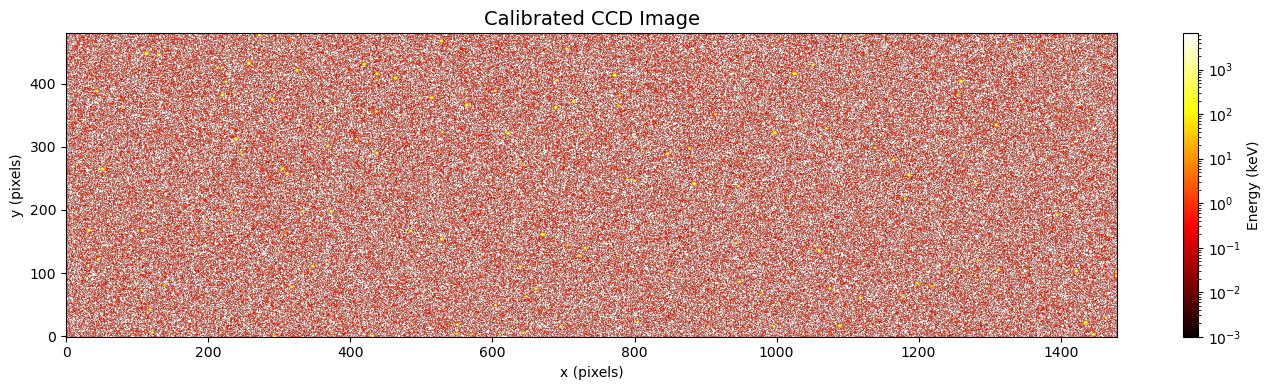

In [16]:
from matplotlib import colors

plt.figure(figsize=(14, 4))
plt.imshow(cal_img.T, aspect='auto', origin='lower', cmap='hot',
           norm=colors.LogNorm(vmin=max(cal_img[cal_img > 0].min(), 1e-3), vmax=cal_img.max()))
plt.colorbar(label='Energy (keV)')
plt.title('Calibrated CCD Image', fontsize=14)
plt.xlabel('x (pixels)')
plt.ylabel('y (pixels)')
plt.tight_layout()
plt.show()

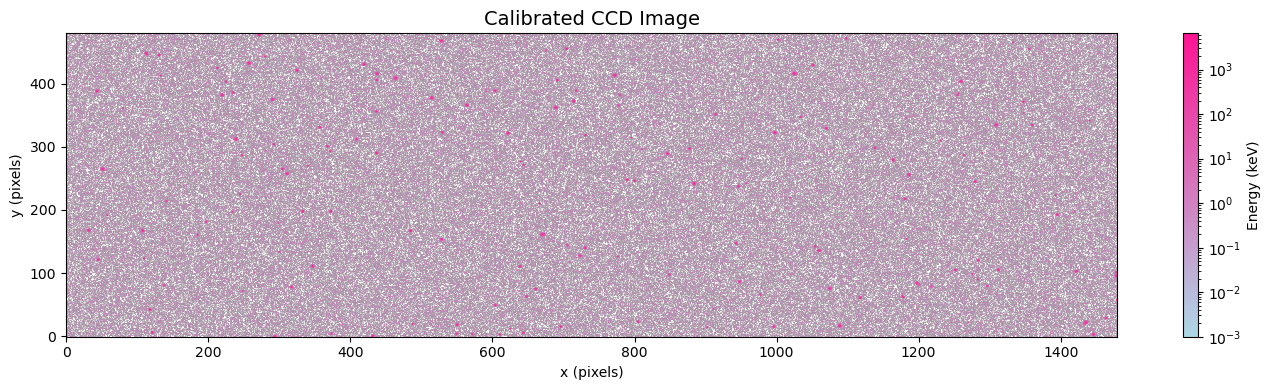

In [17]:
from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list('custom', ['lightblue', 'deeppink'])

plt.figure(figsize=(14, 4))
plt.imshow(cal_img.T, aspect='auto', origin='lower', cmap=custom_cmap,
           norm=colors.LogNorm(vmin=max(cal_img[cal_img > 0].min(), 1e-3), vmax=cal_img.max()))
plt.colorbar(label='Energy (keV)')
plt.title('Calibrated CCD Image', fontsize=14)
plt.xlabel('x (pixels)')
plt.ylabel('y (pixels)')
plt.tight_layout()
plt.show()

In [18]:
# convert image from eV to keV
cal_img = cal_img.T / 1000  # eV to keV and transpose for visualization

### GMM analysis

In [19]:
K_RANGE = [2]

In [20]:
# build samples
X_raw_cut, idx_yx = make_samples(cal_img)

In [21]:
results_cut = fit_gmms_over_K(X_raw_cut, K_RANGE, reg_covar=REG_COVAR, random_state=RANDOM_STATE)

In [22]:
best = results_cut[0]

In [23]:
from matplotlib.colors import ListedColormap

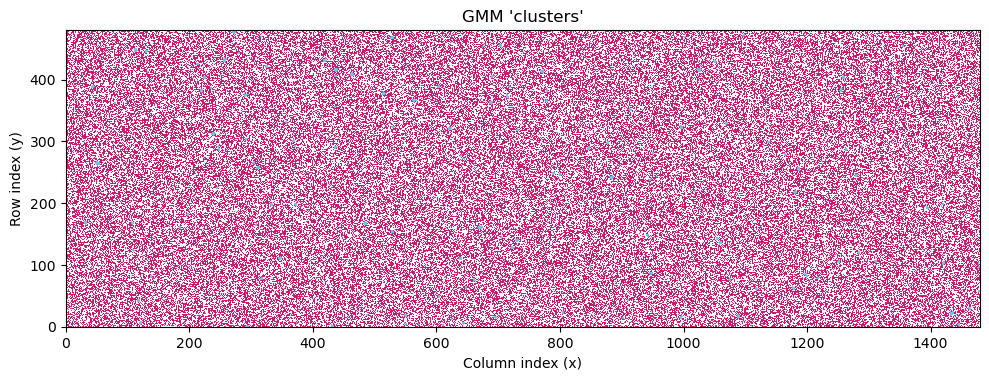

In [24]:
plot_fullframe_clusters(
    idx_yx,
    best["labels"],
    frame_size=cal_img.shape,
    title=f"GMM 'clusters'"
)

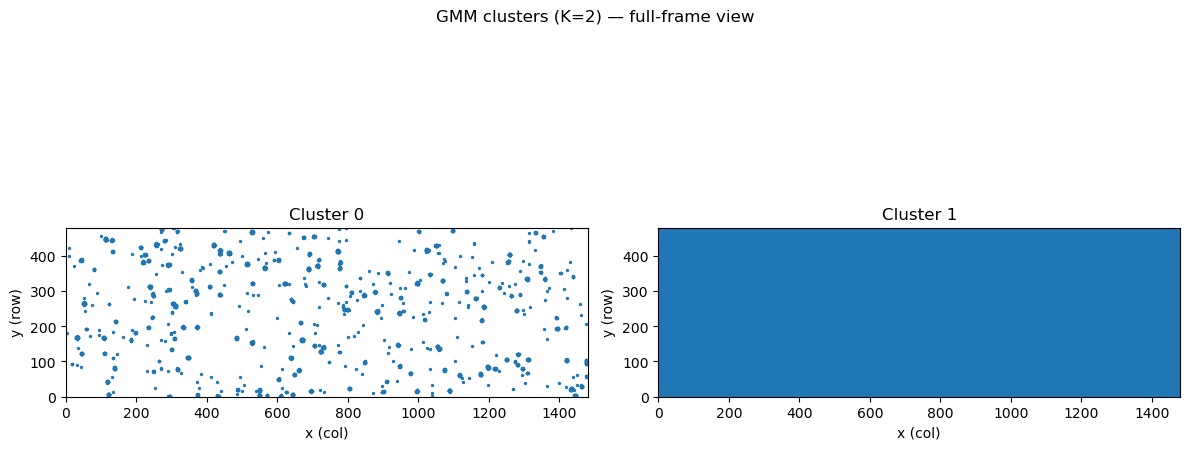

In [25]:
plot_cluster_gallery_on_frame(idx_yx, best, ccd_shape=cal_img.shape)

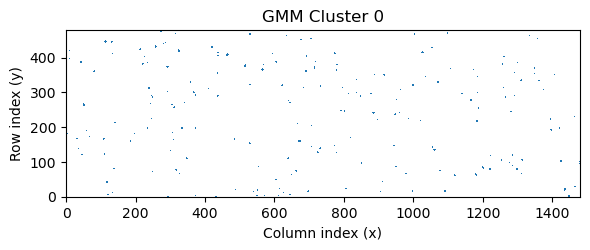

In [26]:
plot_one_cluster(idx_yx, best, ccd_shape=cal_img.shape, cluster_id=0)


In [27]:
import numpy as np
from scipy.ndimage import label as cc_label

def blobs_from_gmm(X_raw, gmm_labels, frame_size, cluster_id):
    """
    X_raw      : (N,3) array [y, x, E]
    gmm_labels : (N,) GMM labels (same order as X_raw)
    frame_size : (H, W)
    cluster_id : GMM component to extract

    Returns:
      blobs   : dict {blob_id: array [[y,x,E], ...]}
      labeled : (H,W) blob-ID image
    """
    H, W = frame_size

    sel = (gmm_labels == cluster_id)
    if not np.any(sel):
        labeled = np.zeros((H, W), dtype=int)
        return {}, labeled

    y = X_raw[sel, 0].astype(int)
    x = X_raw[sel, 1].astype(int)
    E = X_raw[sel, 2].astype(float)

    img = np.zeros((H, W), dtype=np.uint8)
    img[y, x] = 1

    # HARD-CODED 8-connectivity
    labeled = cc_label(img, structure=np.ones((3, 3), dtype=int))[0]

    blob_ids = labeled[y, x]
    blobs = {}

    for bid in np.unique(blob_ids):
        if bid == 0:
            continue
        m = (blob_ids == bid)
        blobs[bid] = np.column_stack([y[m], x[m], E[m]])  # [y,x,E]

    return blobs, labeled


In [28]:
blobs, labeled = blobs_from_gmm(
    X_raw=X_raw_cut,
    gmm_labels=best["labels"],
    frame_size=cal_img.shape,
    cluster_id=0
)

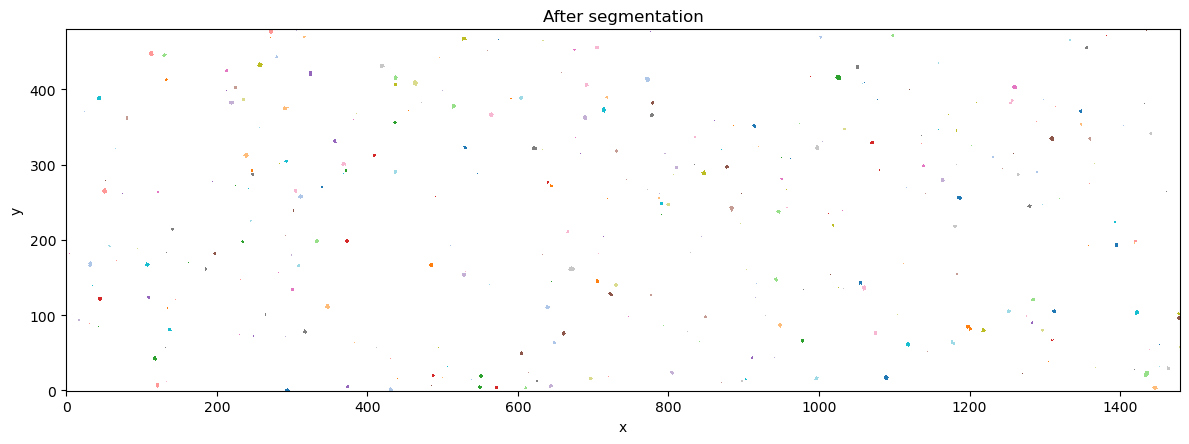

In [29]:
# build a colormap: 0 = white (background), blobs = colors
n_blobs = len(blobs)

colors = [(1, 1, 1, 1)]  # background = white
base = plt.cm.tab20.colors

for i in range(n_blobs):
    colors.append(base[i % len(base)])

cmap = ListedColormap(colors)

plt.figure(figsize=(12, 8))
plt.imshow(labeled, origin="lower", cmap=cmap, interpolation="none")
plt.title("After segmentation")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()


In [30]:
# how many blobs
print("Number of blobs:", len(blobs))

# pick a blob ID (e.g. first one)
bid = list(blobs.keys())[0]

blob = blobs[bid]
print(f"Blob {bid} has {len(blob)} pixels")
print("First 10 pixels [y, x, E]:")
print(blob[:10])

Number of blobs: 412
Blob 1 has 17 pixels
First 10 pixels [y, x, E]:
[[0.00000000e+00 2.91000000e+02 5.60093485e-02]
 [0.00000000e+00 2.92000000e+02 5.49877763e-01]
 [0.00000000e+00 2.93000000e+02 1.12544274e+00]
 [0.00000000e+00 2.94000000e+02 8.57092023e-01]
 [0.00000000e+00 2.95000000e+02 1.57927036e-01]
 [0.00000000e+00 2.96000000e+02 1.14121251e-02]
 [1.00000000e+00 2.91000000e+02 3.37147862e-02]
 [1.00000000e+00 2.92000000e+02 2.17822418e-01]
 [1.00000000e+00 2.93000000e+02 5.61480224e-01]
 [1.00000000e+00 2.94000000e+02 3.14234138e-01]]


In [31]:
df_blobs = pd.DataFrame(
    {
        "blob_id": list(blobs.keys()),
        "points": list(blobs.values())
    }
)

In [32]:
df_blobs.head()

,blob_id,points
0,1,"[[0.0, 291.0, 0.05600934848189354], [0.0, 292...."
1,2,"[[0.0, 429.0, 0.009994356893002987], [0.0, 430..."
2,3,"[[1.0, 1040.0, 0.004248077981173992]]"
3,4,"[[1.0, 1444.0, 0.007387443445622921], [1.0, 14..."
4,5,"[[2.0, 547.0, 0.003875389462336898], [3.0, 548..."


In [33]:
df_blobs["cluster_size"] = df_blobs["points"].apply(len)

In [34]:
df_blobs.head()

,blob_id,points,cluster_size
0,1,"[[0.0, 291.0, 0.05600934848189354], [0.0, 292....",17
1,2,"[[0.0, 429.0, 0.009994356893002987], [0.0, 430...",20
2,3,"[[1.0, 1040.0, 0.004248077981173992]]",1
3,4,"[[1.0, 1444.0, 0.007387443445622921], [1.0, 14...",26
4,5,"[[2.0, 547.0, 0.003875389462336898], [3.0, 548...",22


In [35]:
df_blobs["energy"] = df_blobs["points"].apply(
    lambda pts: np.sum(np.asarray(pts)[:, 2])
)

In [36]:
df_blobs.head()

,blob_id,points,cluster_size,energy
0,1,"[[0.0, 291.0, 0.05600934848189354], [0.0, 292....",17,4.182251
1,2,"[[0.0, 429.0, 0.009994356893002987], [0.0, 430...",20,6.468098
2,3,"[[1.0, 1040.0, 0.004248077981173992]]",1,0.004248
3,4,"[[1.0, 1444.0, 0.007387443445622921], [1.0, 14...",26,6.347001
4,5,"[[2.0, 547.0, 0.003875389462336898], [3.0, 548...",22,0.777435


In [37]:

def weighted_std_xy(points):
    """
    points: array of shape (N,3) with columns [y, x, E]
    Returns: wSTD_y, wSTD_x
    """
    y = points[:, 0]
    x = points[:, 1]
    E = points[:, 2]

    Etot = E.sum()
    if Etot == 0:
        return np.nan, np.nan

    y_bar = np.sum(E * y) / Etot
    x_bar = np.sum(E * x) / Etot

    wSTD_y = np.sqrt(np.sum(E * (y - y_bar)**2) / Etot)
    wSTD_x = np.sqrt(np.sum(E * (x - x_bar)**2) / Etot)

    return wSTD_y, wSTD_x

In [38]:
df_blobs[["wSTD_y", "wSTD_x"]] = (
    df_blobs["points"]
    .apply(lambda pts: pd.Series(weighted_std_xy(pts)))
)

In [39]:
df_blobs.head()

,blob_id,points,cluster_size,energy,wSTD_y,wSTD_x
0,1,"[[0.0, 291.0, 0.05600934848189354], [0.0, 292....",17,4.182251,0.573879,0.914098
1,2,"[[0.0, 429.0, 0.009994356893002987], [0.0, 430...",20,6.468098,0.775887,0.757703
2,3,"[[1.0, 1040.0, 0.004248077981173992]]",1,0.004248,0.000000,0.000000
3,4,"[[1.0, 1444.0, 0.007387443445622921], [1.0, 14...",26,6.347001,0.774044,0.790292
4,5,"[[2.0, 547.0, 0.003875389462336898], [3.0, 548...",22,0.777435,0.932915,1.005352


In [40]:
df_blobs["wSTD_xy"] = np.sqrt(
    0.5 * (df_blobs["wSTD_x"]**2 + df_blobs["wSTD_y"]**2)
)

In [41]:
df_blobs.head()

,blob_id,points,cluster_size,energy,wSTD_y,wSTD_x,wSTD_xy
0,1,"[[0.0, 291.0, 0.05600934848189354], [0.0, 292....",17,4.182251,0.573879,0.914098,0.763188
1,2,"[[0.0, 429.0, 0.009994356893002987], [0.0, 430...",20,6.468098,0.775887,0.757703,0.766849
2,3,"[[1.0, 1040.0, 0.004248077981173992]]",1,0.004248,0.000000,0.000000,0.000000
3,4,"[[1.0, 1444.0, 0.007387443445622921], [1.0, 14...",26,6.347001,0.774044,0.790292,0.782210
4,5,"[[2.0, 547.0, 0.003875389462336898], [3.0, 548...",22,0.777435,0.932915,1.005352,0.969810


lets make these plots!

1. Energy vs. wSTD_xy

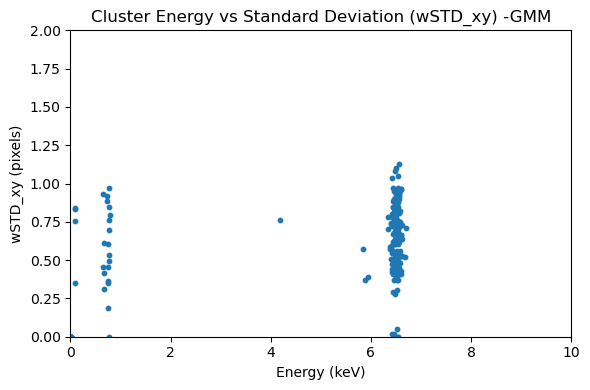

In [42]:
plt.figure(figsize=(6, 4))
plt.scatter(df_blobs["energy"], df_blobs["wSTD_xy"], s=10)
plt.xlabel("Energy (keV)")
plt.ylabel("wSTD_xy (pixels)")
plt.xlim(0,10)
plt.ylim(0,2)
plt.title("Cluster Energy vs Standard Deviation (wSTD_xy) -GMM")
plt.tight_layout()
plt.show()


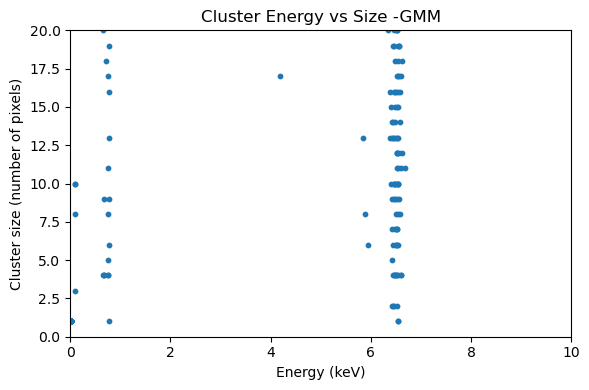

In [43]:
plt.figure(figsize=(6, 4))
plt.scatter(df_blobs["energy"], df_blobs["cluster_size"], s=10)
plt.xlabel("Energy (keV)")
plt.ylabel("Cluster size (number of pixels)")
plt.title("Cluster Energy vs Size -GMM")
plt.xlim(0,10)
plt.ylim(0,20)
plt.tight_layout()
plt.show()

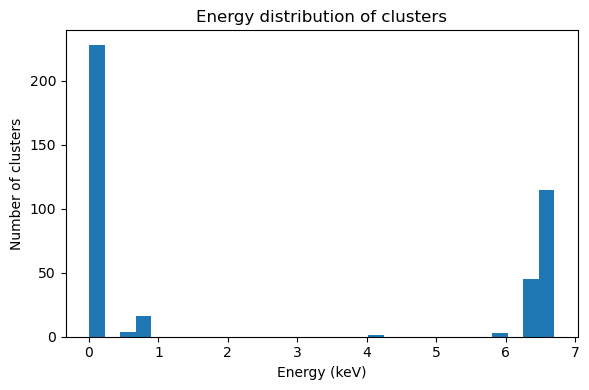

In [44]:
plt.figure(figsize=(6, 4))
plt.hist(df_blobs["energy"], bins=30)
plt.xlabel("Energy (keV)")
plt.ylabel("Number of clusters")
plt.title("Energy distribution of clusters")
plt.tight_layout()
plt.show()

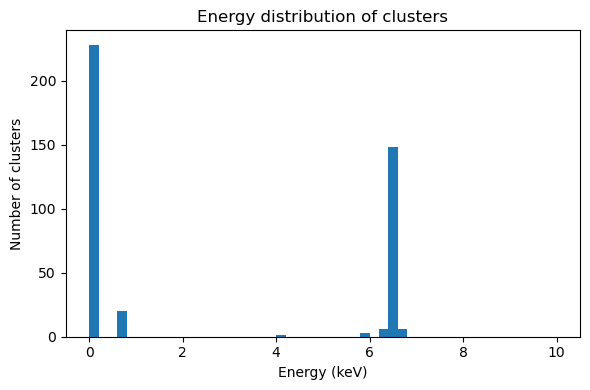

In [45]:
plt.figure(figsize=(6, 4))
plt.hist(df_blobs["energy"], bins=50, range=(0, 10))
plt.xlabel("Energy (keV)")
plt.ylabel("Number of clusters")
plt.title("Energy distribution of clusters")
plt.tight_layout()
plt.show()

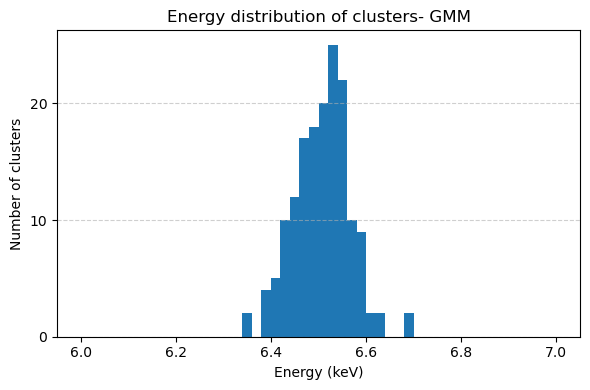

In [84]:
plt.figure(figsize=(6, 4))
plt.hist(df_blobs["energy"], bins=50, range=(6, 7))
# range=(0, 10)
plt.xlabel("Energy (keV)")
plt.ylabel("Number of clusters")
plt.title("Energy distribution of clusters- GMM")

# --- integer y-axis ticks ---
ax = plt.gca()
ymax = int(ax.get_ylim()[1])
ax.set_yticks(np.arange(0, ymax + 1, 10))

# --- light grid aligned with ticks ---
ax.grid(True, axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

### Waders clusters

In [47]:
import uproot

In [48]:
file = "/home/dsalma/damicm-ml/simulation/test_1/out_simulCCDimg_logb9c4085_CCDSensor_PV_55a26z1_2000_s0.root"

In [49]:
with uproot.open(file) as f:
    print(f.keys())

['clustersRec;1', 'pixelizedEvent;1', 'geant4_config;1', 'process_config;1']


In [50]:
clustersRec_tree = f["clustersRec"]

In [51]:
df = clustersRec_tree.arrays(library="pd")

In [52]:
relevant_df = df[["pixels_x", "pixels_y", "pixels_E"]]

In [54]:
import awkward as ak

In [55]:
for c in relevant_df.columns:
    relevant_df[c] = relevant_df[c].apply(lambda x: ak.to_list(x[0]))

relevant_df["event"] = range(len(relevant_df))
relevant_df = relevant_df.explode(["pixels_x", "pixels_y", "pixels_E"]).reset_index(drop=True)

/tmp/ipykernel_2558/91202230.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  relevant_df[c] = relevant_df[c].apply(lambda x: ak.to_list(x[0]))
/tmp/ipykernel_2558/91202230.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  relevant_df[c] = relevant_df[c].apply(lambda x: ak.to_list(x[0]))
/tmp/ipykernel_2558/91202230.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

In [56]:
relevant_df.head()

,pixels_x,pixels_y,pixels_E,event
0,308,165,0.007743,0
1,308,167,0.010822,0
2,309,165,0.02846,0
3,243,225,0.03825,1
4,244,224,0.145776,1


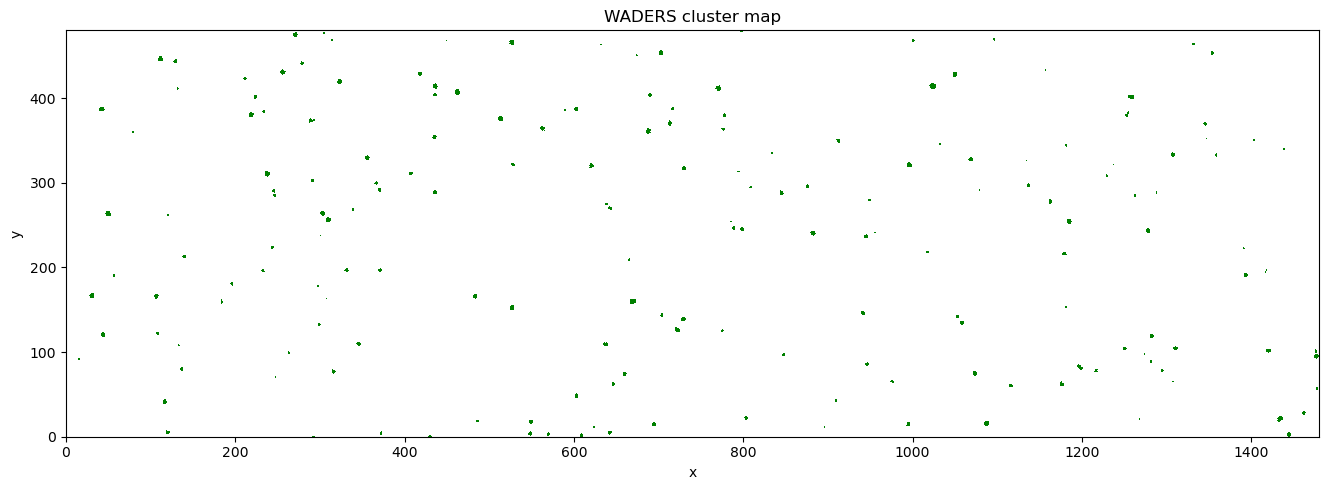

In [57]:
img = np.zeros((480, 1480), dtype=int)

xs = relevant_df["pixels_x"].astype(int).values - 1
ys = relevant_df["pixels_y"].astype(int).values - 1
img[ys, xs] = 1

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["white", "green"])

plt.figure(figsize=(18, 5))
plt.imshow(img, origin="lower", cmap=cmap, interpolation="nearest")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(0, 1480)
plt.ylim(0, 480)
plt.title("WADERS cluster map")
plt.tight_layout()
plt.show()

# finally this looks good!

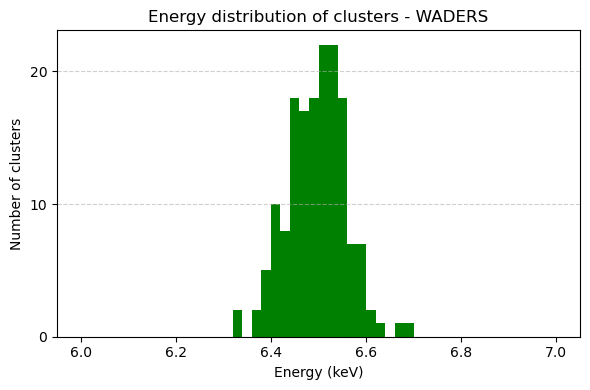

In [85]:
energies = df["Energy"].apply(lambda x: ak.to_list(x[0]))

plt.figure(figsize=(6, 4))
plt.hist(energies, bins=50, color="green", range=(6, 7))
plt.xlabel("Energy (keV)")
plt.ylabel("Number of clusters")
plt.title("Energy distribution of clusters - WADERS")

ax = plt.gca()
ymax = int(ax.get_ylim()[1])
ax.set_yticks(np.arange(0, ymax + 1, 10))
ax.grid(True, axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

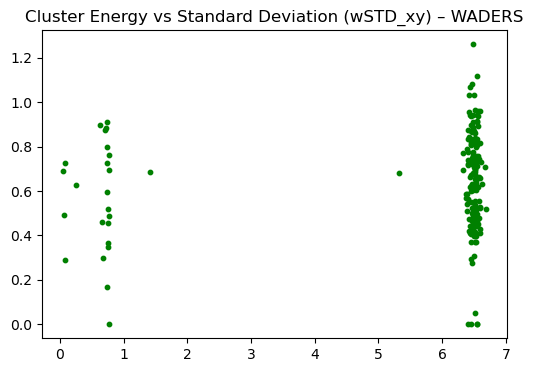

In [59]:
energies = df["Energy"].apply(lambda x: ak.to_list(x[0]))
wstd = df["wSTD_XY"].apply(lambda x: ak.to_list(x[0]))

plt.figure(figsize=(6, 4))
plt.title("Cluster Energy vs Standard Deviation (wSTD_xy) – WADERS")
plt.scatter(energies, wstd, s=10, c="green")

## Validation with mask

In [61]:
d = np.load("/home/dsalma/damicm-ml/simulation/test_1/out_simulCCDimg_logb9c4085_CCDSensor_PV_55a26z1_2000_s0_data.npz")

In [62]:
mask = d["mask"][:1480, :480]

In [63]:
mask.shape

(1480, 480)

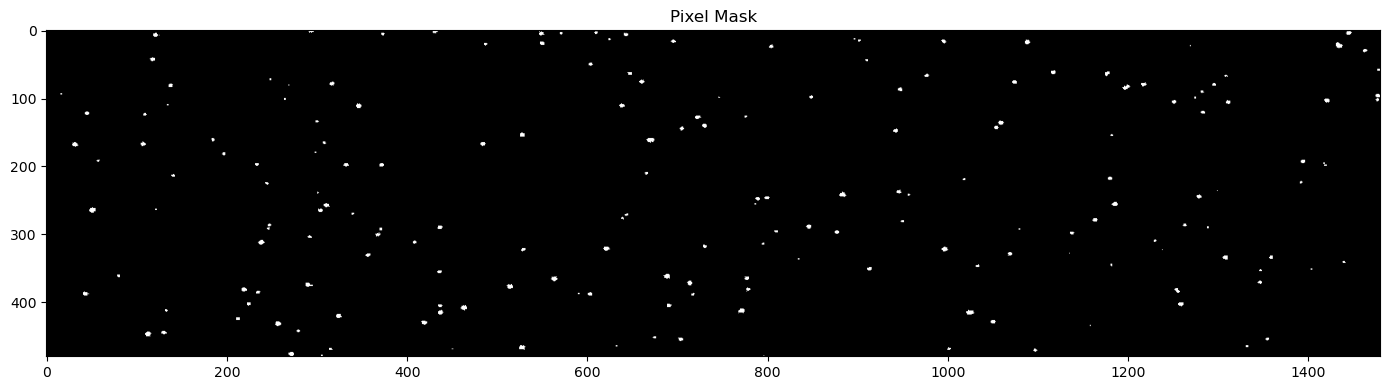

In [64]:
plt.figure(figsize=(14, 4))
plt.imshow(mask.T, cmap='gray', aspect='auto')
plt.title("Pixel Mask")
plt.tight_layout()
plt.show()

In [65]:
import random

# Mask: flip to align y-axis, then extract (y, x) tuples where True
cols, rows = np.where(mask)
mask_yx = set(zip(rows, cols))

# WADERS: one pixel per row
waders_yx = set(zip(relevant_df["pixels_y"], relevant_df["pixels_x"]))

# GMM: unpack points [y, x, E] from each blob
gmm_yx = set()
for pts in df_blobs["points"]:
    for p in pts:
        gmm_yx.add((p[0], p[1]))

print(f"Mask pixels:   {len(mask_yx)}")
print(f"WADERS pixels: {len(waders_yx)}")
print(f"GMM pixels:    {len(gmm_yx)}")
print()
print("Sample mask_yx:", random.sample(list(mask_yx), 5))
print("Sample waders_yx:", random.sample(list(waders_yx), 5))
print("Sample gmm_yx:", random.sample(list(gmm_yx), 5))

Mask pixels:   3344
WADERS pixels: 2737
GMM pixels:    3393

Sample mask_yx: [(np.int64(156), np.int64(526)), (np.int64(424), np.int64(214)), (np.int64(61), np.int64(1116)), (np.int64(265), np.int64(303)), (np.int64(24), np.int64(1434))]
Sample waders_yx: [(300, 369), (83, 139), (428, 1049), (404, 1261), (191, 1394)]
Sample gmm_yx: [(np.float64(245.0), np.float64(800.0)), (np.float64(423.0), np.float64(214.0)), (np.float64(102.0), np.float64(1475.0)), (np.float64(162.0), np.float64(667.0)), (np.float64(112.0), np.float64(641.0))]


In [66]:
# --- Step 2: compute overlaps ---

# intersections
mask_and_waders = mask_yx & waders_yx
mask_and_gmm = mask_yx & gmm_yx
waders_and_gmm = waders_yx & gmm_yx
all_three = mask_yx & waders_yx & gmm_yx

# pixels unique to each method
only_mask = mask_yx - waders_yx - gmm_yx
only_waders = waders_yx - mask_yx - gmm_yx
only_gmm = gmm_yx - mask_yx - waders_yx

print(f"Mask ∩ WADERS:      {len(mask_and_waders)} ({100*len(mask_and_waders)/len(mask_yx):.1f}% of mask)")
print(f"Mask ∩ GMM:         {len(mask_and_gmm)} ({100*len(mask_and_gmm)/len(mask_yx):.1f}% of mask)")
print(f"WADERS ∩ GMM:       {len(waders_and_gmm)} ({100*len(waders_and_gmm)/len(waders_yx):.1f}% of WADERS)")
print(f"All three agree:    {len(all_three)} ({100*len(all_three)/len(mask_yx):.1f}% of mask)")
print()
print(f"Only in mask:       {len(only_mask)}")
print(f"Only in WADERS:     {len(only_waders)}")
print(f"Only in GMM:        {len(only_gmm)}")

Mask ∩ WADERS:      2731 (81.7% of mask)
Mask ∩ GMM:         3170 (94.8% of mask)
WADERS ∩ GMM:       2731 (99.8% of WADERS)
All three agree:    2731 (81.7% of mask)

Only in mask:       174
Only in WADERS:     6
Only in GMM:        223


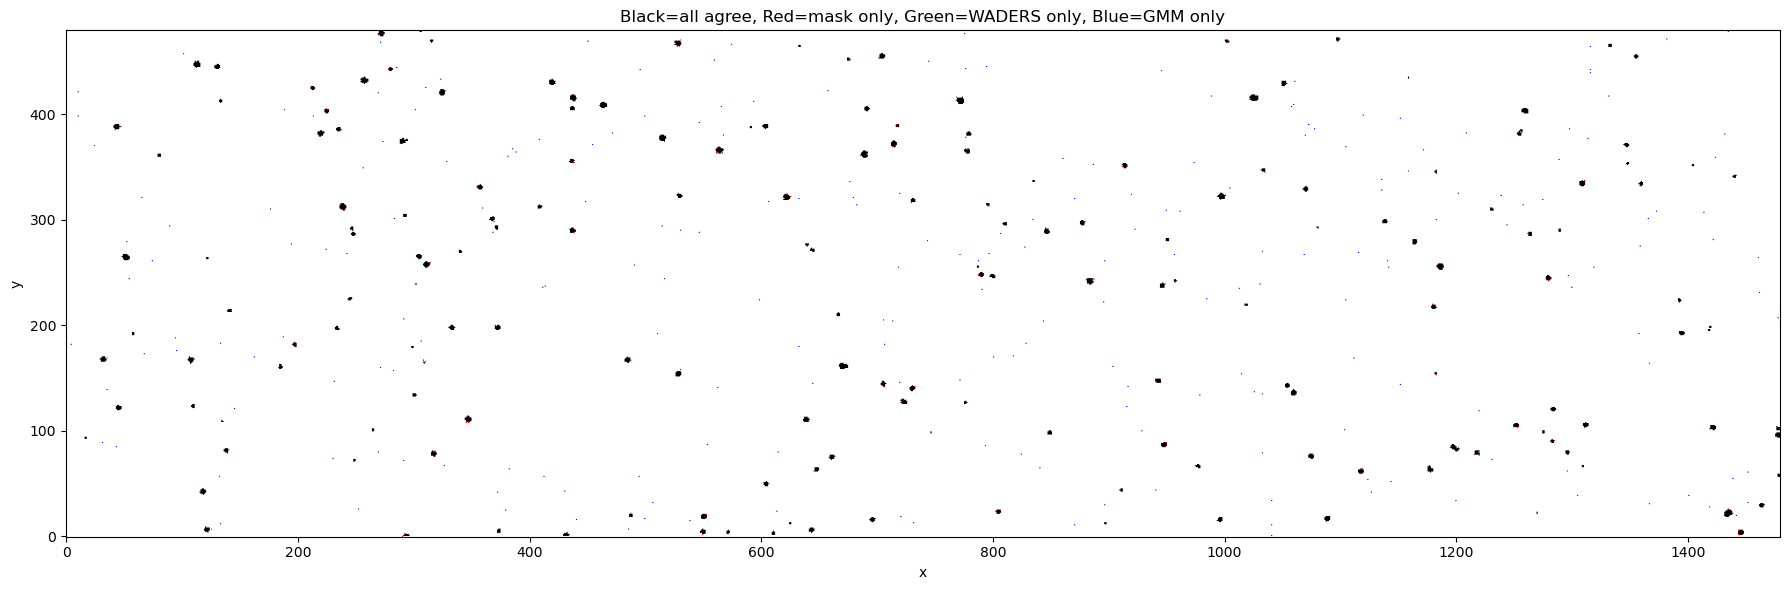

In [67]:
img = np.ones((mask.shape[1], mask.shape[0], 3))  # white background

for (y, x) in all_three:
    img[min(int(y), mask.shape[1]-1), min(int(x), mask.shape[0]-1)] = [0, 0, 0]

for (y, x) in only_mask:
    img[min(int(y), mask.shape[1]-1), min(int(x), mask.shape[0]-1)] = [1, 0, 0]

for (y, x) in only_waders:
    img[min(int(y), mask.shape[1]-1), min(int(x), mask.shape[0]-1)] = [0, 0.7, 0]

for (y, x) in only_gmm:
    img[min(int(y), mask.shape[1]-1), min(int(x), mask.shape[0]-1)] = [0, 0, 1]

fig, ax = plt.subplots(figsize=(18, 6))
ax.imshow(img, aspect='auto', origin='lower')
ax.set_title("Black=all agree, Red=mask only, Green=WADERS only, Blue=GMM only")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()

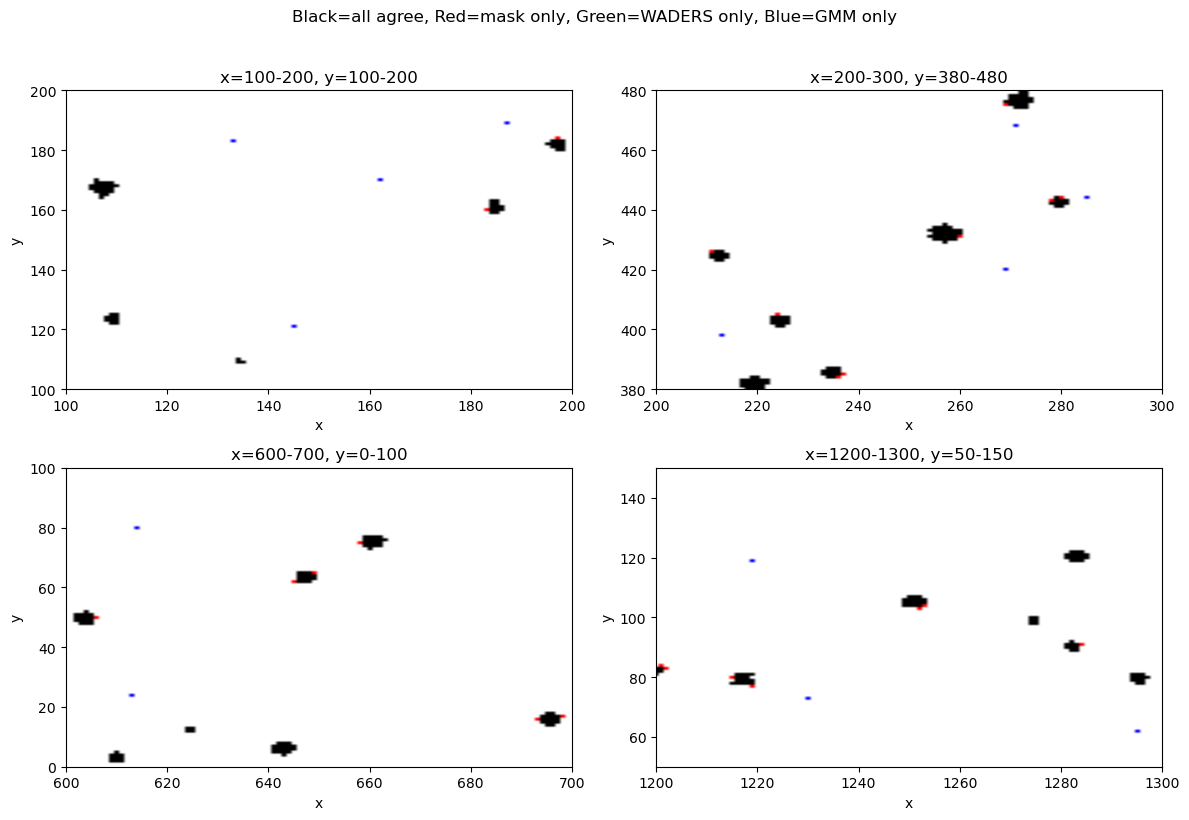

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

regions = [
    (100, 200, 100, 200),
    (200, 300, 380, 480),
    (600, 700, 0, 100),
    (1200, 1300, 50, 150),
]

for ax, (x0, x1, y0, y1) in zip(axes.flat, regions):
    ax.imshow(img, aspect='auto', origin='lower')
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    ax.set_title(f"x={x0}-{x1}, y={y0}-{y1}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.suptitle("Black=all agree, Red=mask only, Green=WADERS only, Blue=GMM only", y=1.02)
plt.tight_layout()
plt.show()

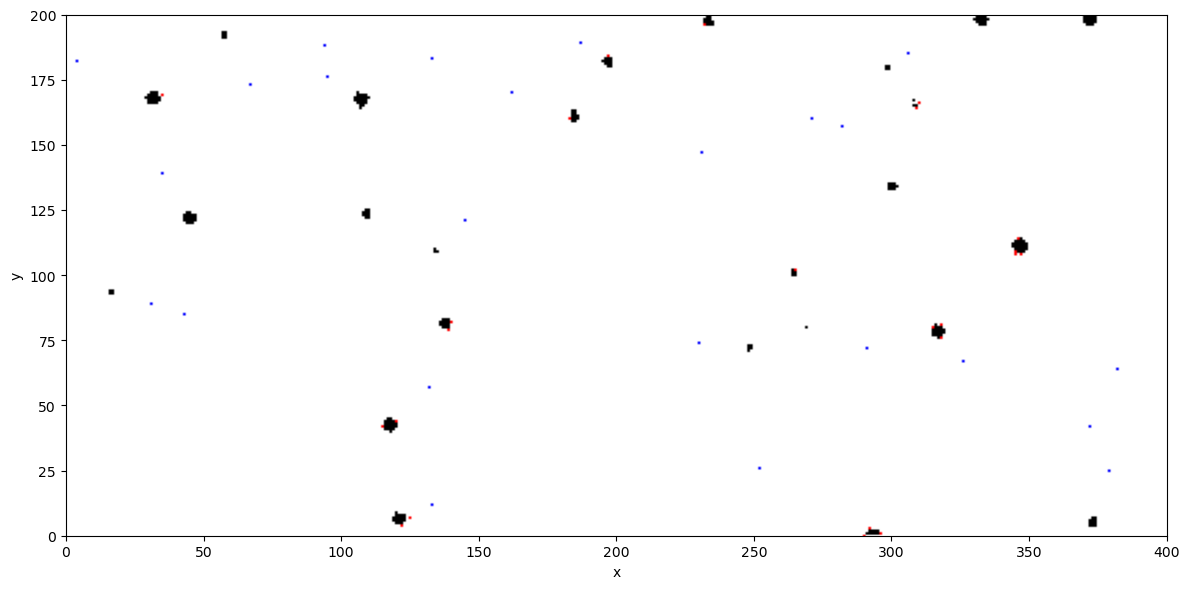

In [69]:
x0, x1, y0, y1 = 0, 400, 0, 200  # change these as needed

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(img, aspect='auto', origin='lower')
ax.set_xlim(x0, x1)
ax.set_ylim(y0, y1)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()

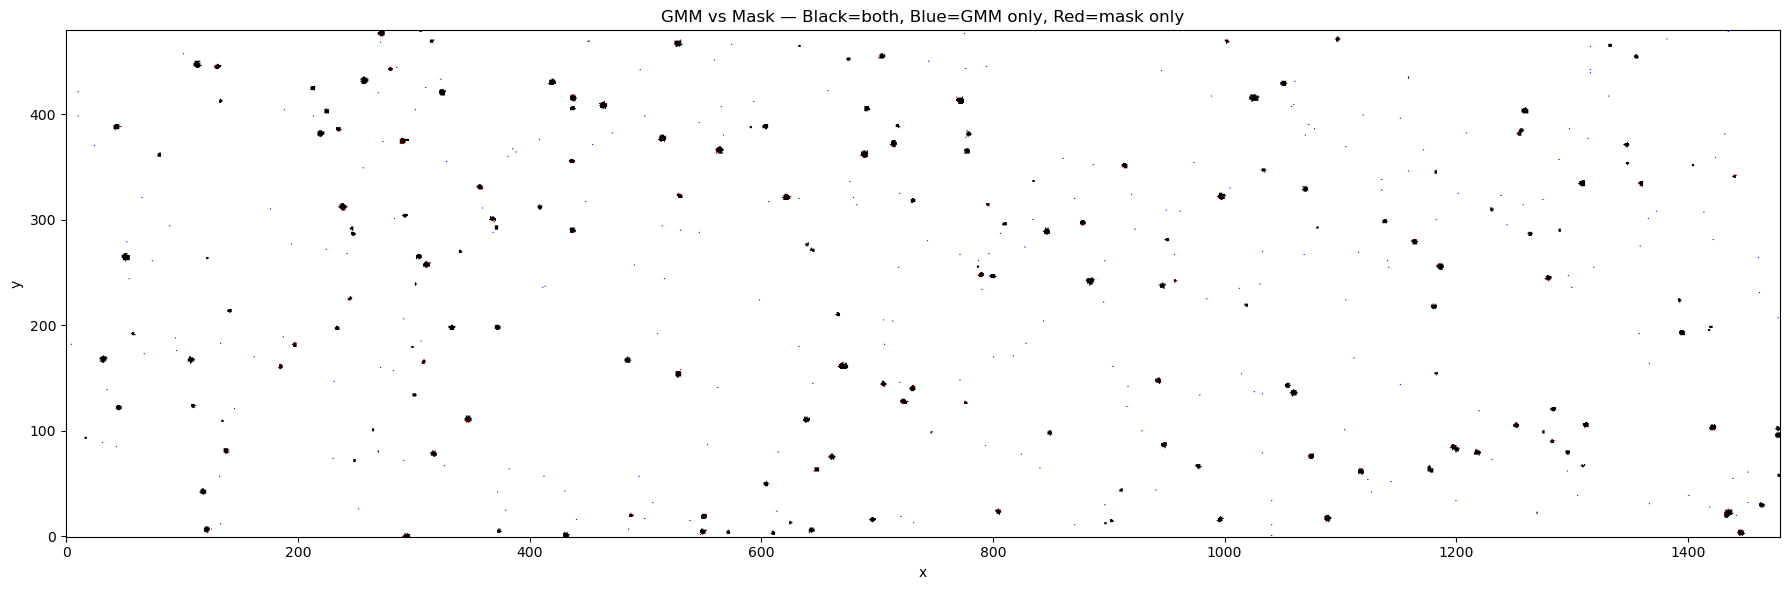

In [70]:
# GMM vs Mask
img_gmm = np.ones((mask.shape[1], mask.shape[0], 3))

gmm_and_mask = mask_yx & gmm_yx
gmm_not_mask = gmm_yx - mask_yx
mask_not_gmm = mask_yx - gmm_yx

for (y, x) in gmm_and_mask:
    img_gmm[min(int(y), mask.shape[1]-1), min(int(x), mask.shape[0]-1)] = [0, 0, 0]
for (y, x) in gmm_not_mask:
    img_gmm[min(int(y), mask.shape[1]-1), min(int(x), mask.shape[0]-1)] = [0, 0, 1]
for (y, x) in mask_not_gmm:
    img_gmm[min(int(y), mask.shape[1]-1), min(int(x), mask.shape[0]-1)] = [1, 0, 0]

fig, ax = plt.subplots(figsize=(18, 6))
ax.imshow(img_gmm, aspect='auto', origin='lower')
ax.set_title("GMM vs Mask — Black=both, Blue=GMM only, Red=mask only")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()

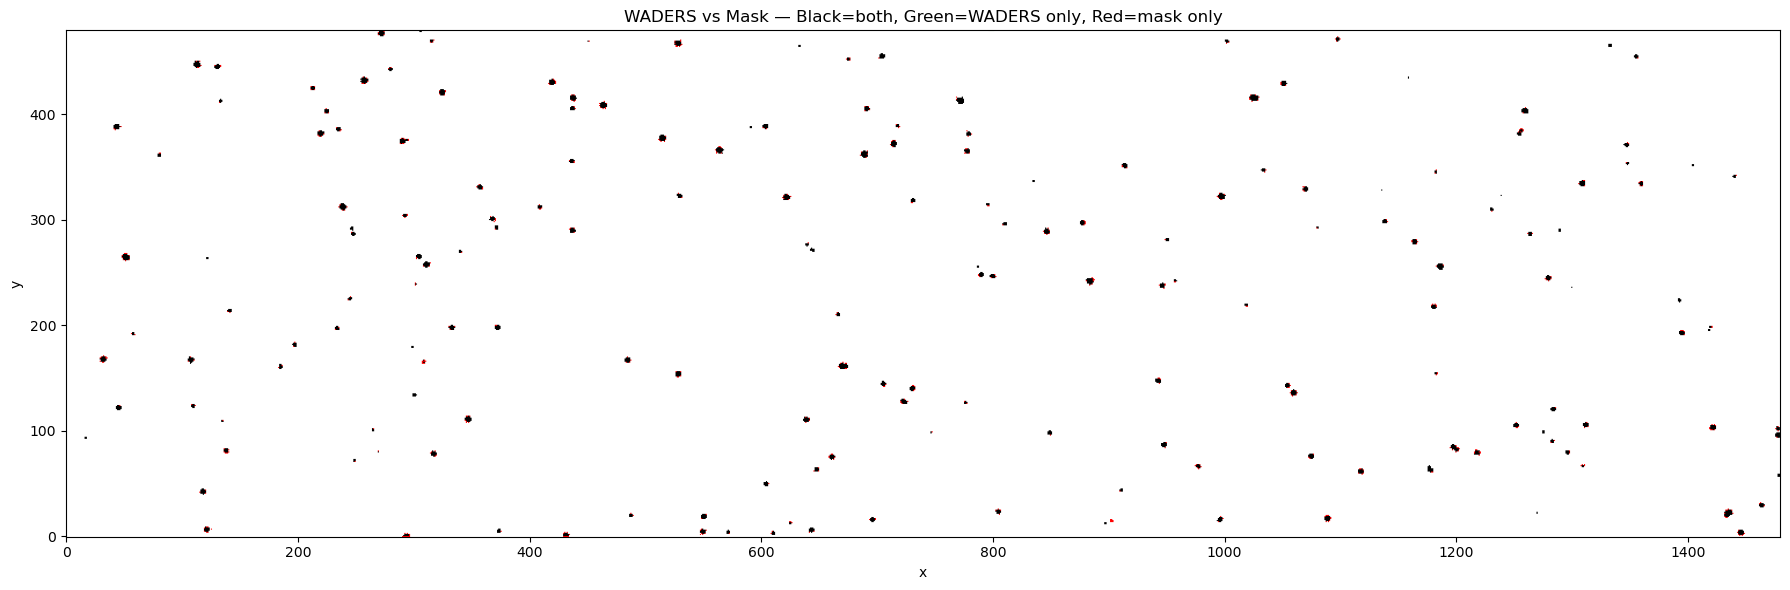

In [71]:
# WADERS vs Mask
img_waders = np.ones((mask.shape[1], mask.shape[0], 3))

waders_and_mask = mask_yx & waders_yx
waders_not_mask = waders_yx - mask_yx
mask_not_waders = mask_yx - waders_yx

for (y, x) in waders_and_mask:
    img_waders[min(int(y), mask.shape[1]-1), min(int(x), mask.shape[0]-1)] = [0, 0, 0]
for (y, x) in waders_not_mask:
    img_waders[min(int(y), mask.shape[1]-1), min(int(x), mask.shape[0]-1)] = [0, 0.7, 0]
for (y, x) in mask_not_waders:
    img_waders[min(int(y), mask.shape[1]-1), min(int(x), mask.shape[0]-1)] = [1, 0, 0]

fig, ax = plt.subplots(figsize=(18, 6))
ax.imshow(img_waders, aspect='auto', origin='lower')
ax.set_title("WADERS vs Mask — Black=both, Green=WADERS only, Red=mask only")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()

GMM seems to include a ton of single electron events. what if i get rid of these?

In [72]:
df_blobs_excl = df_blobs[df_blobs["cluster_size"] > 1].reset_index(drop=True)

In [73]:
# GMM: unpack points [y, x, E] from each blob
new_gmm_yx = set()
for pts in df_blobs_excl["points"]:
    for p in pts:
        new_gmm_yx.add((p[0], p[1]))

In [74]:
print(f"GMM pixels (excluding single pixles):    {len(new_gmm_yx)}")
print(f"Mask pixels:   {len(mask_yx)}")

GMM pixels (excluding single pixles):    3166
Mask pixels:   3344


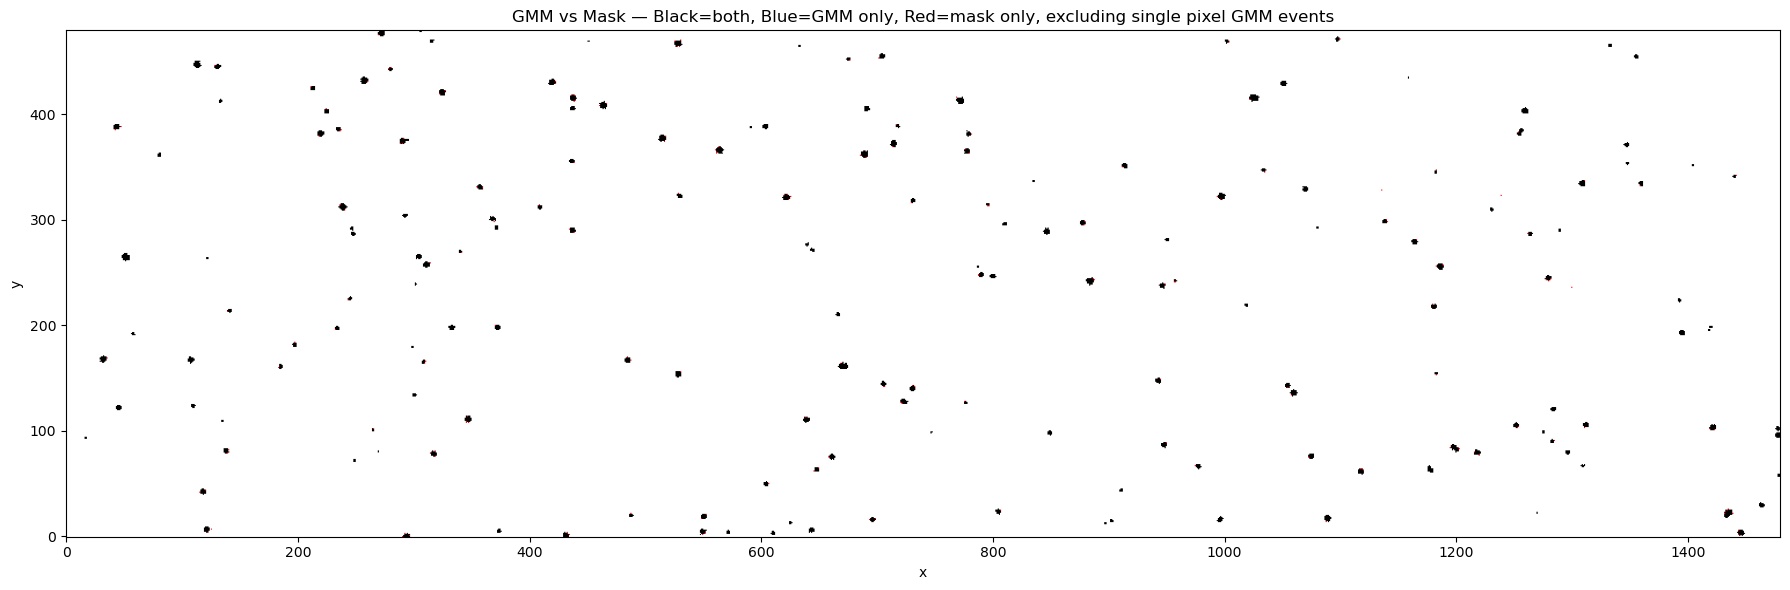

In [75]:
# GMM vs Mask
img_gmm = np.ones((mask.shape[1], mask.shape[0], 3))

gmm_and_mask = mask_yx & new_gmm_yx
gmm_not_mask = new_gmm_yx - mask_yx
mask_not_gmm = mask_yx - new_gmm_yx

for (y, x) in gmm_and_mask:
    img_gmm[min(int(y), mask.shape[1]-1), min(int(x), mask.shape[0]-1)] = [0, 0, 0]
for (y, x) in gmm_not_mask:
    img_gmm[min(int(y), mask.shape[1]-1), min(int(x), mask.shape[0]-1)] = [0, 0, 1]
for (y, x) in mask_not_gmm:
    img_gmm[min(int(y), mask.shape[1]-1), min(int(x), mask.shape[0]-1)] = [1, 0, 0]

fig, ax = plt.subplots(figsize=(18, 6))
ax.imshow(img_gmm, aspect='auto', origin='lower')
ax.set_title("GMM vs Mask — Black=both, Blue=GMM only, Red=mask only, excluding single pixel GMM events")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()

In [76]:
# intersections
mask_and_waders = mask_yx & waders_yx
mask_and_gmm = mask_yx & new_gmm_yx
waders_and_gmm = waders_yx & new_gmm_yx
all_three = mask_yx & waders_yx & new_gmm_yx

# pixels unique to each method
only_mask = mask_yx - waders_yx - new_gmm_yx
only_waders = waders_yx - mask_yx - new_gmm_yx
only_gmm = new_gmm_yx - mask_yx - waders_yx

print(f"Mask ∩ WADERS:      {len(mask_and_waders)} ({100*len(mask_and_waders)/len(mask_yx):.1f}% of mask)")
print(f"Mask ∩ GMM:         {len(mask_and_gmm)} ({100*len(mask_and_gmm)/len(mask_yx):.1f}% of mask)")
print(f"WADERS ∩ GMM:       {len(waders_and_gmm)} ({100*len(waders_and_gmm)/len(waders_yx):.1f}% of WADERS)")
print(f"All three agree:    {len(all_three)} ({100*len(all_three)/len(mask_yx):.1f}% of mask)")
print()
print(f"Only in mask:       {len(only_mask)}")
print(f"Only in WADERS:     {len(only_waders)}")
print(f"Only in GMM:        {len(only_gmm)}")

Mask ∩ WADERS:      2731 (81.7% of mask)
Mask ∩ GMM:         3166 (94.7% of mask)
WADERS ∩ GMM:       2728 (99.7% of WADERS)
All three agree:    2728 (81.6% of mask)

Only in mask:       175
Only in WADERS:     6
Only in GMM:        0


In [77]:
signal = d["signal"][:1480, :480]

In [78]:
signal = signal/1000  # eV to keV

Number of connected clusters: 194


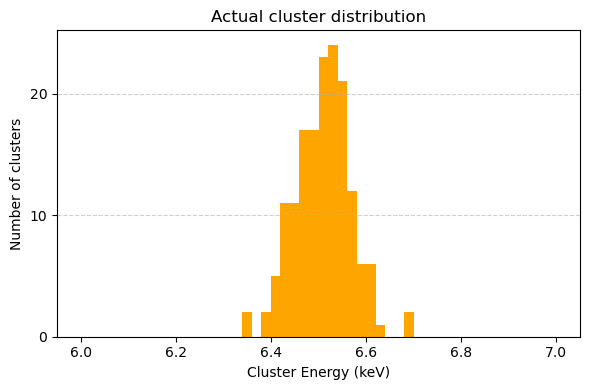

In [86]:
from scipy import ndimage

# label connected components in the mask
labeled, num_clusters = ndimage.label(mask)
print(f"Number of connected clusters: {num_clusters}")

# for each cluster, sum the energy values from the signal array
cluster_energies = []
for i in range(1, num_clusters + 1):
    cluster_mask = labeled == i
    cluster_energies.append(signal[cluster_mask].sum())

cluster_energies = np.array(cluster_energies)

plt.figure(figsize=(6, 4))
plt.hist(cluster_energies, bins=50, color="orange", range=(6, 7))
plt.xlabel("Cluster Energy (keV)")
plt.ylabel("Number of clusters")
plt.title("Actual cluster distribution")

ax = plt.gca()
ymax = int(ax.get_ylim()[1])
ax.set_yticks(np.arange(0, ymax + 1, 10))
ax.grid(True, axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

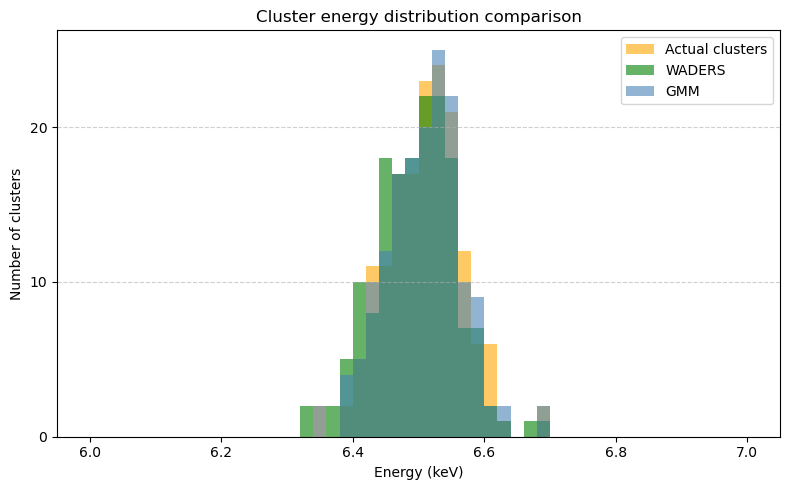

In [87]:
fig, ax = plt.subplots(figsize=(8, 5))

# --- Actual clusters ---
ax.hist(cluster_energies, bins=50, range=(6, 7),
        color="orange", alpha=0.6, label="Actual clusters")

# --- WADERS ---
energies = df["Energy"].apply(lambda x: ak.to_list(x[0]))
ax.hist(energies, bins=50, range=(6, 7),
        color="green", alpha=0.6, label="WADERS")

# --- GMM ---
ax.hist(df_blobs["energy"], bins=50, range=(6, 7),
        color="steelblue", alpha=0.6, label="GMM")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Number of clusters")
ax.set_title("Cluster energy distribution comparison")
ax.legend()

ymax = int(ax.get_ylim()[1])
ax.set_yticks(np.arange(0, ymax + 1, 10))
ax.grid(True, axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

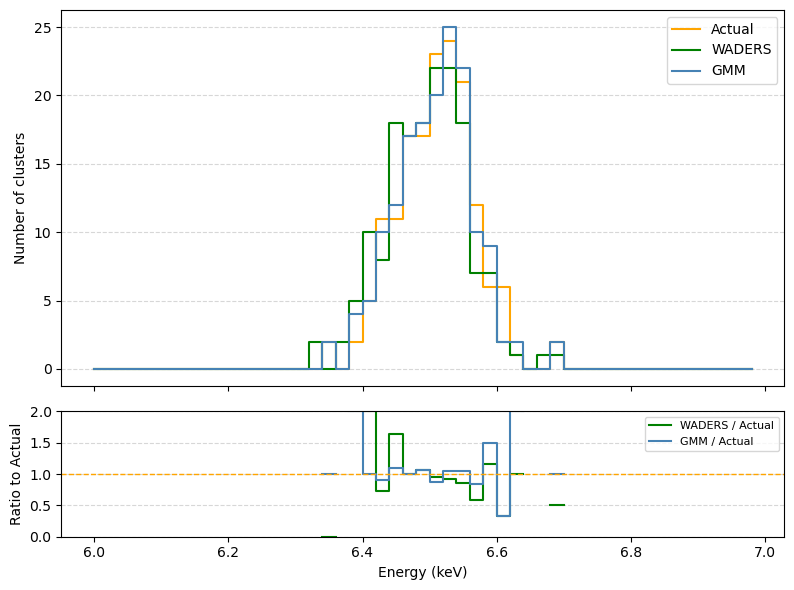

In [89]:
fig, (ax_main, ax_ratio) = plt.subplots(2, 1, figsize=(8, 6), 
                                          gridspec_kw={"height_ratios": [3, 1]},
                                          sharex=True)

bins = np.linspace(6, 7, 51)

counts_actual, _ = np.histogram(cluster_energies, bins=bins)
counts_waders, _ = np.histogram(list(energies), bins=bins)
counts_gmm, _    = np.histogram(df_blobs["energy"], bins=bins)

bin_centers = (bins[:-1] + bins[1:]) / 2

# Main panel
for counts, label, color in [
    (counts_actual, "Actual", "orange"),
    (counts_waders, "WADERS", "green"),
    (counts_gmm,   "GMM",    "steelblue"),
]:
    ax_main.step(bins[:-1], counts, where="post", label=label, color=color, linewidth=1.5)

ax_main.set_ylabel("Number of clusters")
ax_main.legend()
ax_main.grid(True, axis="y", linestyle="--", alpha=0.5)

# Ratio panel (WADERS / Actual and GMM / Actual)
with np.errstate(divide="ignore", invalid="ignore"):
    ratio_waders = np.where(counts_actual > 0, counts_waders / counts_actual, np.nan)
    ratio_gmm    = np.where(counts_actual > 0, counts_gmm    / counts_actual, np.nan)

ax_ratio.step(bins[:-1], ratio_waders, where="post", color="green",     linewidth=1.5, label="WADERS / Actual")
ax_ratio.step(bins[:-1], ratio_gmm,    where="post", color="steelblue", linewidth=1.5, label="GMM / Actual")
ax_ratio.axhline(1, color="orange", linestyle="--", linewidth=1)
ax_ratio.set_ylabel("Ratio to Actual")
ax_ratio.set_xlabel("Energy (keV)")
ax_ratio.set_ylim(0, 2)
ax_ratio.legend(fontsize=8)
ax_ratio.grid(True, axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()